In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import os

#List all files
files=os.listdir("C:/Users/preet/Downloads/MIS Report")
print(files)

['table10_ratios.csv', 'table1_assets.csv', 'table1_liabilities_2020onwards.csv', 'table1_liabilities_upto2019.csv', 'table2_earnings.csv', 'table2_expenses.csv', 'table6_npa.csv']


## Data Cleaning:

In [4]:
path='C:/Users/preet/Downloads/MIS Report/'

for file in os.listdir(path):
    print(f"\n=== {file} ===")
    df=pd.read_csv(path+file, encoding='utf-8')
    print(df.shape)
    print(df.columns.tolist())
    print(df.head(2))


=== table10_ratios.csv ===
(617, 11)
['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10']
                                          Unnamed: 0 Unnamed: 1 Unnamed: 2  \
0  BANK GROUP-WISE SELECT  RATIOS OF SCHEDULED CO...        NaN        NaN   
1                                                NaN        NaN        NaN   

  Unnamed: 3 Unnamed: 4 Unnamed: 5 Unnamed: 6 Unnamed: 7 Unnamed: 8  \
0        NaN        NaN        NaN        NaN        NaN        NaN   
1        NaN        NaN        NaN        NaN        NaN        NaN   

  Unnamed: 9 Unnamed: 10  
0        NaN         NaN  
1        NaN         NaN  

=== table1_assets.csv ===
(1986, 43)
['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unname

In [5]:
#Check each file to find where actual data begins
for file in os.listdir(path):
    print(f"\n=== {file} ===")
    df=pd.read_csv(path+file, encoding='utf-8', header=None)
    print(df.iloc[0:10, 0:4])


=== table10_ratios.csv ===
                                                   0           1  \
0                                                NaN         NaN   
1  BANK GROUP-WISE SELECT  RATIOS OF SCHEDULED CO...         NaN   
2                                                NaN         NaN   
3                                       (In Percent)         NaN   
4                                                NaN         NaN   
5                                                NaN         NaN   
6                                                NaN        Year   
7                                                NaN  2024-25      
8                                                NaN         NaN   
9                                                NaN         NaN   

                                2                                       3  
0                             NaN                                     NaN  
1                             NaN                                     N

In [6]:
npa=pd.read_csv(path+'table6_npa.csv', encoding='utf-8', header=None)

#Print rows 5-15 to find exact header location
print(npa.iloc[5:20, 0:10])

       0                      1                2                         3  \
5    NaN                    NaN   As on March 31                       NaN   
6   Year                   Bank       Gross NPAs                       NaN   
7    NaN                    NaN  Opening Balance  Addition during the Year   
8    NaN                    NaN              (2)                       (3)   
9   2025         BANK OF BARODA        31,833.63                  9,310.13   
10   NaN          BANK OF INDIA        29,182.77                  7,588.56   
11   NaN    BANK OF MAHARASHTRA         3,833.05                  1,687.86   
12   NaN            CANARA BANK        40,605.00                  8,544.00   
13   NaN  CENTRAL BANK OF INDIA        11,340.34                  3,494.58   
14   NaN            INDIAN BANK        21,106.31                  5,786.46   
15   NaN   INDIAN OVERSEAS BANK         6,794.43                  3,627.54   
16   NaN   PUNJAB AND SIND BANK         4,665.35                

In [7]:
#Load NPA data
npa_raw=pd.read_csv(path+'table6_npa.csv', encoding='utf-8', header=None)

#Extract data from row 9 onwards
npa=npa_raw.iloc[9:].copy()
npa.columns=['year','bank','gross_npa_opening','gross_npa_addition',
             'gross_npa_reduction','gross_npa_writeoff','gross_npa_closing',
             'net_npa_opening','net_npa_closing','extra']

#Drop extra column
npa=npa.drop(columns=['extra'])

#Forward fill year column
npa['year']=npa['year'].ffill()

#Remove rows where bank is null
npa=npa.dropna(subset=['bank'])

#Clean numeric columns
numeric_cols=['gross_npa_opening','gross_npa_addition','gross_npa_reduction',
              'gross_npa_writeoff','gross_npa_closing','net_npa_opening','net_npa_closing']

for col in numeric_cols:
    npa[col]=npa[col].astype(str).str.replace(',','').str.strip()
    npa[col]=pd.to_numeric(npa[col], errors='coerce')

#Clean year column
npa['year']=npa['year'].astype(str).str[:4].str.strip()
npa=npa[npa['year'].str.isnumeric()]
npa['year']=npa['year'].astype(int)

print("Shape:", npa.shape)
print("\nYears available:", sorted(npa['year'].unique()))
print("\nSample:")
print(npa.head())

Shape: (1976, 9)

Years available: [np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Sample:
    year                   bank  gross_npa_opening  gross_npa_addition  \
9   2025         BANK OF BARODA           31833.63             9310.13   
10  2025          BANK OF INDIA           29182.77             7588.56   
11  2025    BANK OF MAHARASHTRA            3833.05             1687.86   
12  2025            CANARA BANK           40605.00             8544.00   
13  2025  CENTRAL BANK OF INDIA           11340.34             3494.58   

    gross_npa_reduction  gross_npa_writeoff  gross_npa_closing  \
9               4320.06             8988.82           27834.88   
10              7265.87             7756.5

In [8]:
#Load earnings data
earn_raw=pd.read_csv(path+'table2_earnings.csv', encoding='utf-8', header=None)
print(earn_raw.iloc[5:12, 0:5])

       0                    1  \
5    NaN                  NaN   
6    NaN                  NaN   
7   Year                Banks   
8   2025       BANK OF BARODA   
9    NaN        BANK OF INDIA   
10   NaN  BANK OF MAHARASHTRA   
11   NaN          CANARA BANK   

                                                  2  \
5                                               NaN   
6                                 I.Interest Earned   
7   a)   Interest/Discount earned on advances/bills   
8                                         93,050.88   
9                                         50,044.94   
10                                        19,291.51   
11                                        87,789.30   

                             3  \
5                          NaN   
6                          NaN   
7   b)   Income on investments   
8                    25,948.76   
9                    17,205.03   
10                    5,360.43   
11                   24,595.57   

                     

In [9]:
print(earn_raw.iloc[6:8, :])

     0      1                                                2   \
6   NaN    NaN                                I.Interest Earned   
7  Year  Banks  a)   Interest/Discount earned on advances/bills   

                           3   \
6                         NaN   
7  b)   Income on investments   

                                                  4            5          6   \
6                                                NaN          NaN        NaN   
7  c)   Interest on balances with RBI and other i...  d)   Others  Total (I)   

                                        7   \
6                          II.Other Income   
7  a)   Commission, exchange and brokerage   

                                              8   \
6                                            NaN   
7  b)   Net profit (loss) on sale of investments   

                                                  9   \
6                                                NaN   
7  c)   Net profit (loss) on revaluation of inves

In [10]:
earn=earn_raw.iloc[8:].copy()
earn.columns=['year','bank','interest_advances','income_investments',
              'interest_rbi','other_interest','total_interest',
              'commission','profit_investments','profit_revaluation',
              'profit_land','profit_exchange','misc_income',
              'total_other_income','total_income']

#Forward fill year
earn['year']=earn['year'].ffill()

#Drop null banks
earn=earn.dropna(subset=['bank'])

#Clean numerics
numeric_cols=[c for c in earn.columns if c not in ['year','bank']]
for col in numeric_cols:
    earn[col]=earn[col].astype(str).str.replace(',','').str.strip()
    earn[col]=pd.to_numeric(earn[col], errors='coerce')

#Clean year
earn['year']=earn['year'].astype(str).str[:4].str.strip()
earn=earn[earn['year'].str.isnumeric()]
earn['year']=earn['year'].astype(int)

print("Shape:", earn.shape)
print("\nYears:", sorted(earn['year'].unique()))
print("\nSample:")
print(earn.head())

Shape: (1978, 15)

Years: [np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Sample:
    year                   bank  interest_advances  income_investments  \
8   2025         BANK OF BARODA           93050.88            25948.76   
9   2025          BANK OF INDIA           50044.94            17205.03   
10  2025    BANK OF MAHARASHTRA           19291.51             5360.43   
11  2025            CANARA BANK           87789.30            24595.57   
12  2025  CENTRAL BANK OF INDIA           22339.08            10092.40   

    interest_rbi  other_interest  total_interest  commission  \
8        1756.37          685.63       121441.64     3365.77   
9        3195.29          381.03        70826.30     19

In [11]:
rat_raw=pd.read_csv(path+'table10_ratios.csv', encoding='utf-8', header=None)
print(rat_raw.iloc[4:12, 0:6])

      0           1                                            2  \
4   NaN         NaN                                          NaN   
5   NaN         NaN                                          NaN   
6   NaN        Year                                       Ratios   
7   NaN  2024-25                        1.  Cash - Deposit Ratio   
8   NaN         NaN                   2.  Credit - Deposit Ratio   
9   NaN         NaN               3.  Investment - Deposit Ratio   
10  NaN         NaN    4.  (Credit + Investment) - Deposit Ratio   
11  NaN         NaN  5.   Ratio of deposits to total liabilities   

                                         3                   4  \
4                                      NaN                 NaN   
5                           As on March 31                 NaN   
6   STATE BANK OF INDIA AND ITS ASSOCIATES  NATIONALISED BANKS   
7                                                                
8                                                        

In [12]:
print(rat_raw.iloc[4:12, :])

     0           1                                            2   \
4   NaN         NaN                                          NaN   
5   NaN         NaN                                          NaN   
6   NaN        Year                                       Ratios   
7   NaN  2024-25                        1.  Cash - Deposit Ratio   
8   NaN         NaN                   2.  Credit - Deposit Ratio   
9   NaN         NaN               3.  Investment - Deposit Ratio   
10  NaN         NaN    4.  (Credit + Investment) - Deposit Ratio   
11  NaN         NaN  5.   Ratio of deposits to total liabilities   

                                        3                   4   \
4                                      NaN                 NaN   
5                           As on March 31                 NaN   
6   STATE BANK OF INDIA AND ITS ASSOCIATES  NATIONALISED BANKS   
7                                                                
8                                                        

In [13]:
#Merge on year and bank
df=pd.merge(npa, earn, on=['year','bank'], how='inner')

print("Merged shape:", df.shape)
print("\nYears:", sorted(df['year'].unique()))
print("\nBanks:", df['bank'].nunique())
print("\nSample:")
print(df[['year','bank','gross_npa_closing','total_income']].head())

Merged shape: (1949, 22)

Years: [np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Banks: 146

Sample:
   year                   bank  gross_npa_closing  total_income
0  2025         BANK OF BARODA           27834.88     138088.97
1  2025          BANK OF INDIA           21748.89      79819.92
2  2025    BANK OF MAHARASHTRA            4184.52      28401.62
3  2025            CANARA BANK           31530.00     142207.87
4  2025  CENTRAL BANK OF INDIA            9224.78      39520.44


## Analysis:

In [14]:
#Derive key metrics
df['npa_addition_rate']=df['gross_npa_addition']/df['gross_npa_opening']*100
df['writeoff_rate']=df['gross_npa_writeoff']/df['gross_npa_opening']*100
df['npa_to_income']=df['gross_npa_closing']/df['total_income']*100

#Aggregate by year for trend analysis
yearly=df.groupby('year').agg(
    total_gross_npa=('gross_npa_closing','sum'),
    total_npa_addition=('gross_npa_addition','sum'),
    total_writeoff=('gross_npa_writeoff','sum'),
    total_income=('total_income','sum'),
    avg_npa_to_income=('npa_to_income','mean'),
    bank_count=('bank','count')
).reset_index()

print(yearly[['year','total_gross_npa','total_npa_addition','total_income']].to_string())

    year  total_gross_npa  total_npa_addition  total_income
0   2005        118746.98            40811.20     380454.44
1   2006        102193.66            42759.80     441511.40
2   2007        100973.14            52422.88     549432.61
3   2008        112618.30            69962.40     737746.66
4   2009        136656.41           104691.75     927404.00
5   2010        169401.63           139159.39     988892.45
6   2011        195946.32           140879.72    1142381.67
7   2012        285806.65           215041.44    1483255.21
8   2013        388106.62           276412.33    1722782.13
9   2014        528762.28           380175.31    1938450.44
10  2015        646670.32           417276.30    2146370.24
11  2016       1223894.57           884384.94    2270033.81
12  2017       1583582.10           831645.99    2410690.64
13  2018       1855931.21          1048203.50    2170033.26
14  2019       1822919.64           598228.17    2621004.37
15  2020       1730224.14           7112

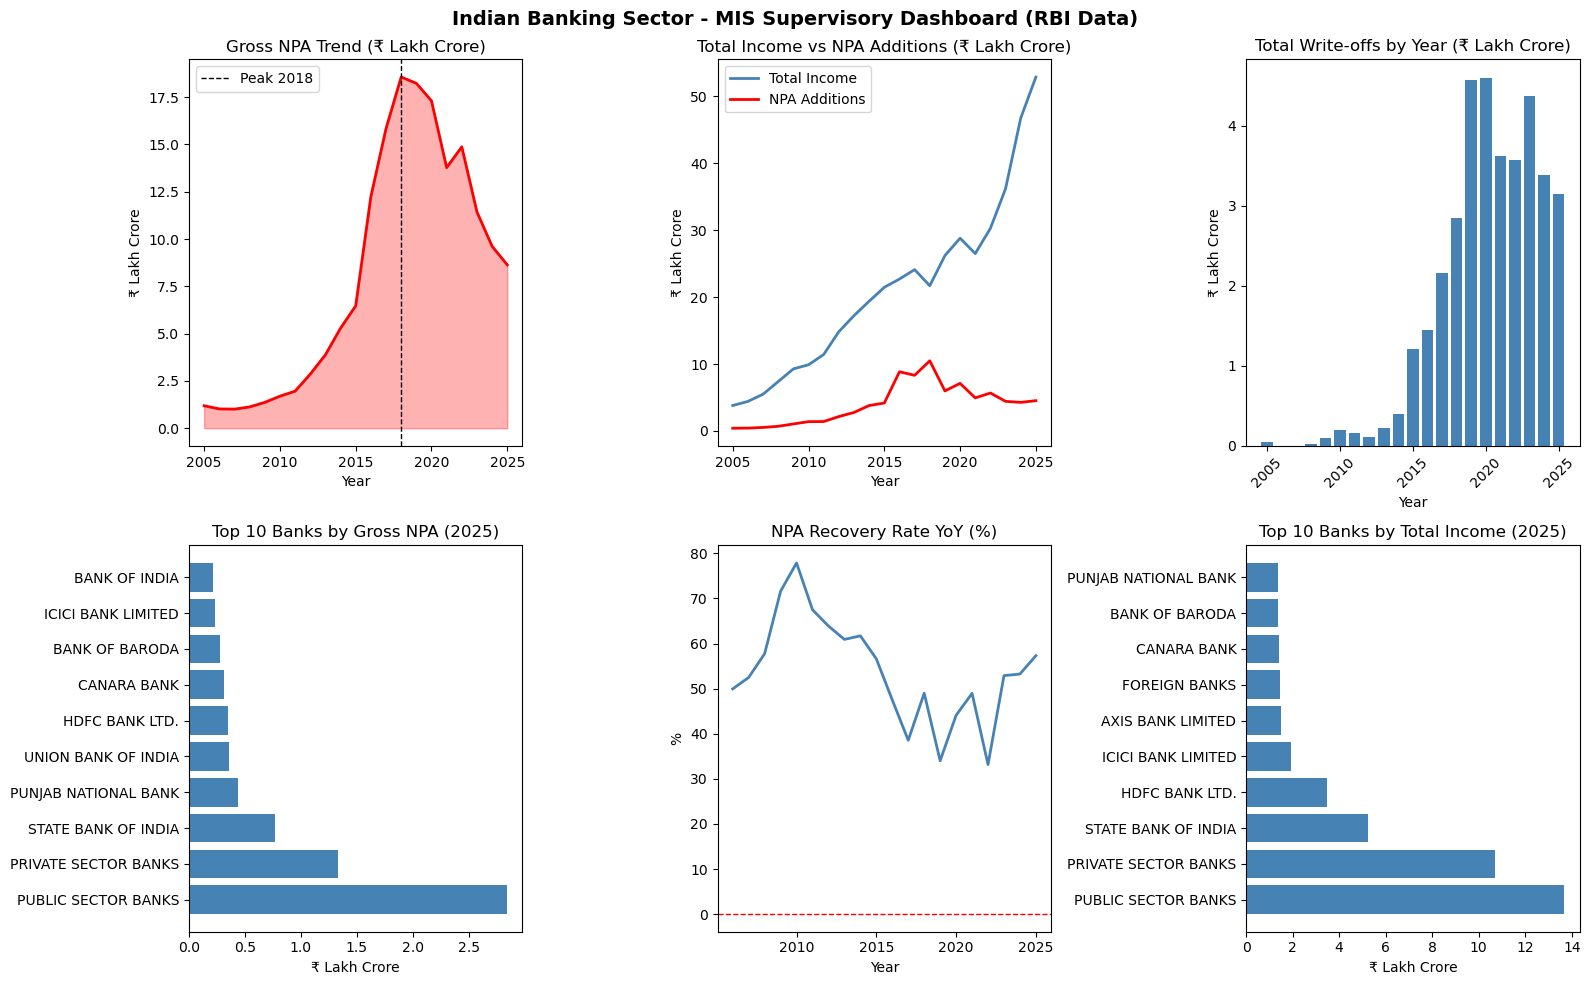

Saved.


In [16]:
fig, axes=plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Indian Banking Sector - MIS Supervisory Dashboard (RBI Data)', fontsize=14, fontweight='bold')

#1. Gross NPA trend
axes[0,0].fill_between(yearly['year'], yearly['total_gross_npa']/100000, alpha=0.3, color='red')
axes[0,0].plot(yearly['year'], yearly['total_gross_npa']/100000, color='red', linewidth=2)
axes[0,0].set_title('Gross NPA Trend (₹ Lakh Crore)')
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('₹ Lakh Crore')
axes[0,0].axvline(2018, color='black', linestyle='--', linewidth=1, label='Peak 2018')
axes[0,0].legend()

#2. Total income vs NPA additions
axes[0,1].plot(yearly['year'], yearly['total_income']/100000, color='steelblue', linewidth=2, label='Total Income')
axes[0,1].plot(yearly['year'], yearly['total_npa_addition']/100000, color='red', linewidth=2, label='NPA Additions')
axes[0,1].set_title('Total Income vs NPA Additions (₹ Lakh Crore)')
axes[0,1].set_xlabel('Year')
axes[0,1].set_ylabel('₹ Lakh Crore')
axes[0,1].legend()

#3. Write-off trend
axes[0,2].bar(yearly['year'], yearly['total_writeoff']/100000, color='steelblue')
axes[0,2].set_title('Total Write-offs by Year (₹ Lakh Crore)')
axes[0,2].set_xlabel('Year')
axes[0,2].set_ylabel('₹ Lakh Crore')
axes[0,2].tick_params(axis='x', rotation=45)

#4. Top 10 banks by gross NPA in 2025
top_npa=df[df['year']==2025].nlargest(10, 'gross_npa_closing')
axes[1,0].barh(top_npa['bank'], top_npa['gross_npa_closing']/100000, color='steelblue')
axes[1,0].set_title('Top 10 Banks by Gross NPA (2025)')
axes[1,0].set_xlabel('₹ Lakh Crore')

#5. NPA recovery rate trend
yearly['recovery_rate']=(yearly['total_gross_npa'].shift(1)-yearly['total_gross_npa']+yearly['total_npa_addition'])/yearly['total_gross_npa'].shift(1)*100
axes[1,1].plot(yearly['year'], yearly['recovery_rate'], color='steelblue', linewidth=2)
axes[1,1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1,1].set_title('NPA Recovery Rate YoY (%)')
axes[1,1].set_xlabel('Year')
axes[1,1].set_ylabel('%')

#6. Top 10 banks by total income 2025
top_income=df[df['year']==2025].nlargest(10, 'total_income')
axes[1,2].barh(top_income['bank'], top_income['total_income']/100000, color='steelblue')
axes[1,2].set_title('Top 10 Banks by Total Income (2025)')
axes[1,2].set_xlabel('₹ Lakh Crore')

plt.tight_layout()
plt.savefig('rbi_mis_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [17]:
#SQL analysis
conn=sqlite3.connect(':memory:')
df.to_sql('banking', conn, index=False, if_exists='replace')

queries={
    'Top 5 NPA Banks 2025': """
        SELECT bank, gross_npa_closing, net_npa_closing,
               ROUND(gross_npa_writeoff/gross_npa_opening*100, 2) as writeoff_rate_pct
        FROM banking
        WHERE year=2025 AND bank NOT IN ('PUBLIC SECTOR BANKS','PRIVATE SECTOR BANKS')
        ORDER BY gross_npa_closing DESC
        LIMIT 5
    """,
    'NPA Trend by Decade': """
        SELECT 
            CASE 
                WHEN year BETWEEN 2005 AND 2010 THEN '2005-2010'
                WHEN year BETWEEN 2011 AND 2015 THEN '2011-2015'
                WHEN year BETWEEN 2016 AND 2020 THEN '2016-2020'
                ELSE '2021-2025'
            END as period,
            ROUND(AVG(gross_npa_closing/total_income*100), 2) as avg_npa_to_income_pct,
            ROUND(SUM(gross_npa_addition)/1000, 0) as total_npa_additions_thousands
        FROM banking
        GROUP BY period
        ORDER BY period
    """,
    'Income Growth vs NPA Growth 2025': """
        SELECT bank,
               ROUND(total_income/1000, 2) as total_income_thousands,
               ROUND(gross_npa_closing/1000, 2) as gross_npa_thousands,
               ROUND(gross_npa_closing/total_income*100, 2) as npa_to_income_pct
        FROM banking
        WHERE year=2025 AND bank NOT IN ('PUBLIC SECTOR BANKS','PRIVATE SECTOR BANKS','FOREIGN BANKS')
        ORDER BY npa_to_income_pct DESC
        LIMIT 10
    """
}

for name, query in queries.items():
    print(f"\n--- {name} ---")
    print(pd.read_sql_query(query, conn))


--- Top 5 NPA Banks 2025 ---
                   bank  gross_npa_closing  net_npa_closing  writeoff_rate_pct
0   STATE BANK OF INDIA           76880.20         19666.92              24.10
1  PUNJAB NATIONAL BANK           44081.60          4290.55              21.58
2   UNION BANK OF INDIA           35350.38          5969.29              26.99
3        HDFC BANK LTD.           35222.64         11320.43              38.00
4           CANARA BANK           31530.00          7353.00              35.34

--- NPA Trend by Decade ---
      period  avg_npa_to_income_pct  total_npa_additions_thousands
0  2005-2010                  31.45                          450.0
1  2011-2015                  20.30                         1430.0
2  2016-2020                  56.28                         4074.0
3  2021-2025                  32.12                         2383.0

--- Income Growth vs NPA Growth 2025 ---
                                    bank  total_income_thousands  \
0                     

In [18]:
from scipy import stats
from sklearn.linear_model import LinearRegression

#1. Hypothesis test: Is NPA to income ratio significantly different pre and post 2018 peak?
pre_peak=df[df['year']<=2018]['npa_to_income'].dropna()
post_peak=df[df['year']>2018]['npa_to_income'].dropna()

t_stat, p_value=stats.ttest_ind(pre_peak, post_peak)
print("=== Hypothesis Test: NPA Ratio Pre vs Post 2018 Peak ===")
print(f"Pre-2018 mean NPA/Income: {pre_peak.mean():.2f}%")
print(f"Post-2018 mean NPA/Income: {post_peak.mean():.2f}%")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Significant difference: {p_value < 0.05}")

#2. Correlation: NPA additions vs total income
corr, p_corr=stats.pearsonr(yearly['total_npa_addition'].dropna(), yearly['total_income'].dropna())
print(f"\n=== Correlation: NPA Additions vs Total Income ===")
print(f"Pearson correlation: {corr:.4f}")
print(f"P-value: {p_corr:.6f}")

#3. NPA recovery forecast
recovery_data=yearly.dropna(subset=['recovery_rate'])
X=recovery_data['year'].values.reshape(-1,1)
y=recovery_data['recovery_rate'].values
model=LinearRegression()
model.fit(X, y)
print(f"\n=== NPA Recovery Rate Trend ===")
print(f"Annual change in recovery rate: {model.coef_[0]:.2f}% per year")
print(f"R² score: {model.score(X, y):.4f}")
next_year=model.predict([[2026]])
print(f"Forecasted recovery rate 2026: {next_year[0]:.2f}%")

=== Hypothesis Test: NPA Ratio Pre vs Post 2018 Peak ===
Pre-2018 mean NPA/Income: 33.79%
Post-2018 mean NPA/Income: 38.27%
T-statistic: -1.3242
P-value: 0.185641
Significant difference: False

=== Correlation: NPA Additions vs Total Income ===
Pearson correlation: 0.5508
P-value: 0.009661

=== NPA Recovery Rate Trend ===
Annual change in recovery rate: -0.97% per year
R² score: 0.2446
Forecasted recovery rate 2026: 43.72%


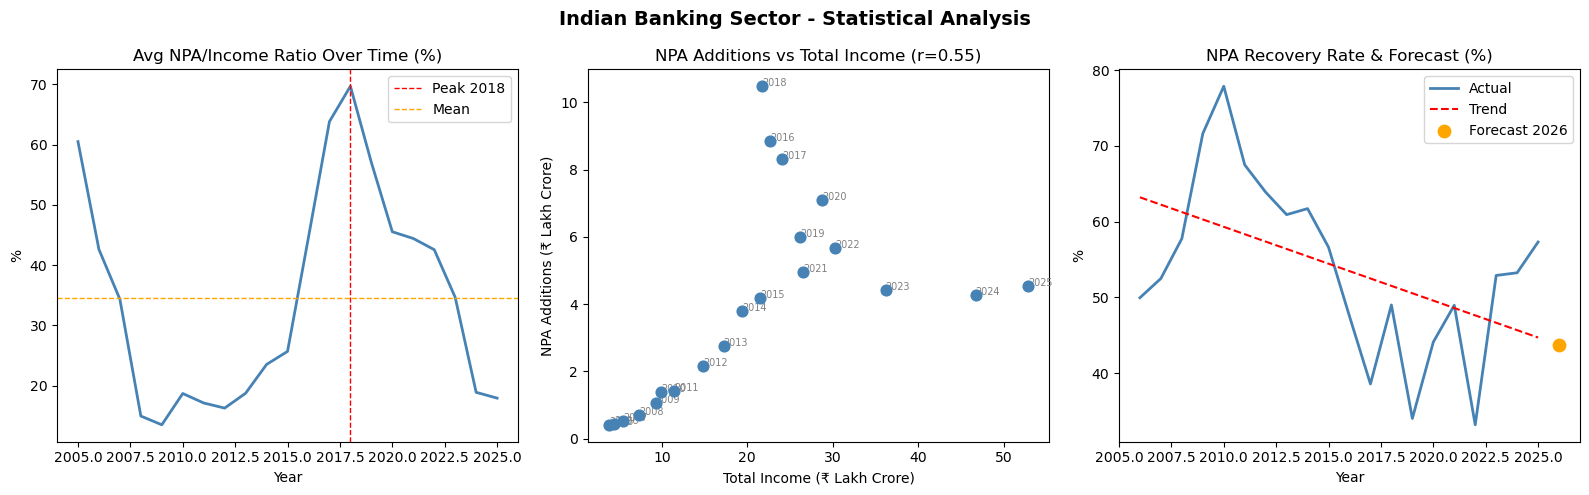

Saved.


In [20]:
fig, axes=plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Indian Banking Sector - Statistical Analysis', fontsize=14, fontweight='bold')

#1. NPA to income ratio over time
yearly_npa_ratio=df.groupby('year')['npa_to_income'].mean().reset_index()
axes[0].plot(yearly_npa_ratio['year'], yearly_npa_ratio['npa_to_income'], color='steelblue', linewidth=2)
axes[0].axvline(2018, color='red', linestyle='--', linewidth=1, label='Peak 2018')
axes[0].axhline(yearly_npa_ratio['npa_to_income'].mean(), color='orange', linestyle='--', linewidth=1, label='Mean')
axes[0].set_title('Avg NPA/Income Ratio Over Time (%)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('%')
axes[0].legend()

#2. NPA additions vs total income scatter
axes[1].scatter(yearly['total_income']/100000, yearly['total_npa_addition']/100000,
                color='steelblue', s=60, zorder=5)
for _, row in yearly.iterrows():
    axes[1].annotate(str(int(row['year'])),
                    (row['total_income']/100000, row['total_npa_addition']/100000),
                    fontsize=7, color='grey')
axes[1].set_title(f'NPA Additions vs Total Income (r={corr:.2f})')
axes[1].set_xlabel('Total Income (₹ Lakh Crore)')
axes[1].set_ylabel('NPA Additions (₹ Lakh Crore)')

#3. Recovery rate with forecast
axes[2].plot(recovery_data['year'], recovery_data['recovery_rate'], color='steelblue', linewidth=2, label='Actual')
axes[2].plot(recovery_data['year'], model.predict(X), color='red', linestyle='--', linewidth=1.5, label='Trend')
axes[2].scatter([2026], next_year, color='orange', zorder=5, s=80, label='Forecast 2026')
axes[2].set_title('NPA Recovery Rate & Forecast (%)')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('%')
axes[2].legend()

plt.tight_layout()
plt.savefig('rbi_statistical_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")